<div style="font-family: 'Helvetica Neue', sans-serif;">

### Testing Hypotheses (Individual Signals) via IC

##### *The Basic Idea*

Each candidate signal (hypothesis) must stand on its own before we being combining things. The basic question we're asking for each signal is simple: *on a given day, if I rank all the stocks in our universe by signal strength (i.e., "signal likes this most" to "signal likes this least"), does that ranking actually line up with price action in the future (i.e. forward returns)?*

For now, that's the entire scope of this analysis. We're not (yet) asking whether the signal drives returns in some backtest with position sizing and slippage baked in. At this point, we simply want to understand whether the underlying idea/signal/hypothesis is any good, namely: is there real information in the ranking, or is it noise?

---
##### *Why Rank Correlation?*

It's tempting to sort stocks into buckets (e.g. top 20%, bottom 20%) and compare average returns. That's a legitimate thing to look at eventually, but it throws away much of the information and is sensitive to the manner in which bucketing is defined. ***Spearman rank correlation*** between the signal and forward returns uses the full cross-section every day, which gives a cleaner, less arbitrary read on whether the ordering itself carries information.

Concretely: on day *T*, take the signal's score for every stock, take each stock's return from *T* to *T + horizon*, and correlate the ranks. That single number is the IC for that day. Repeating this process for every day generates an IC time series.

---
##### *What to Look for in IC*

A single day's IC means little on its own: daily cross-sectional correlations are noisy no matter how good the signal is. Hence, it's crucial to look at the distribution over time:

- ***Mean IC*** — the average edge. Anything consistently above ~0.02-0.03 is considered meaningful in practice (this isn't a field where you're expecting 0.3)
- ***IC volatility and the Information Ratio (mean / std), IR*** — a signal with a decent mean IC that's very volatile is less trustworthy than one that's smaller but more stable. The IR tells you whether the edge is dependable.
- ***% of days with positive IC*** — a rough hit-rate check. It's worth knowing whether a "positive mean" signal only edges out because of a handful of huge days.
- ***Shape of cumulative IC*** — it's important to visualize whether the edge accumulates steadily across the whole sample, or if it's mainly one strong stretch (say, one bull run) that contributes most of the edge? Roughly analagous test to the % positive IC days, though easier to visualize.

---
##### *Horizon Variation*

A signal could have predictive power over the next day but not over the next month, or vice versa. It's important to consider a range of forward return windows to capture effects with statistical power across time frames; hence, we compute IC across several horizons (e.g. 1, 5, 10, 20, 40 days) and assess how it decays. Fast-decaying signals are only useful if you're actually able to trade on them quickly (and cost-effectively); slower, more persistent signals are more forgiving from an execution standpoint even if the peak IC is lower.

</div>

In [5]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.fetch_data import get_sp500_universe, fetch_universe_prices, compute_returns, START_DATE, END_DATE
from src.signals import momentum_naive
from src.evaluation import compute_forward_returns, compute_ic_series, summarize_ic, compute_decay_curve
from src.visualize import plot_ic_series, plot_decay_curves, plot_cumulative_ic

import pandas as pd

In [6]:
universe = get_sp500_universe()
print(f"{len(universe)} tickers across {universe['Sector'].nunique()} sectors")

503 tickers across 11 sectors


In [7]:
close, volume = fetch_universe_prices(universe["Symbol"].tolist(), start=START_DATE, end=END_DATE)
print(f"Close shape: {close.shape}")
close.tail()

Fetching batch 1 / 13 (40 tickers)...


[*********************100%***********************]  40 of 40 completed


Fetching batch 2 / 13 (40 tickers)...


[*********************100%***********************]  40 of 40 completed


Fetching batch 3 / 13 (40 tickers)...


...

[*********************100%***********************]  40 of 40 completed


Fetching batch 13 / 13 (23 tickers)...


[*********************100%***********************]  23 of 23 completed


Close shape: (1901, 503)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACN,ADBE,ADI,AEE,AEP,...,WST,WTW,WY,WYNN,XEL,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-21,132.860001,327.739990,256.100006,144.100006,99.669998,140.860001,227.160004,382.809998,109.940002,130.479996,...,359.005493,288.820007,23.610001,94.629997,78.720001,117.000000,147.169998,88.919998,262.399994,75.349998
2026-07-22,133.460007,325.890015,253.300003,140.050003,100.570000,140.089996,218.360001,386.730011,112.010002,133.070007,...,358.176025,286.510010,23.820000,94.370003,80.190002,116.139999,147.570007,88.680000,262.750000,74.190002
2026-07-23,139.740005,321.660004,256.920013,137.570007,100.750000,138.740005,212.169998,380.200012,113.269997,134.919998,...,355.247955,288.369995,23.639999,96.769997,80.769997,116.870003,147.369995,89.650002,256.950012,74.570000
2026-07-24,138.570007,333.019989,259.359985,141.100006,103.059998,146.990005,225.110001,371.859985,113.779999,135.539993,...,327.985779,295.109985,23.940001,96.919998,81.669998,119.750000,148.919998,91.349998,259.920013,75.349998
2026-07-27,137.889999,336.910004,256.910004,146.860001,104.489998,154.059998,237.750000,371.890015,112.110001,133.589996,...,331.033752,302.640015,23.910000,99.699997,80.709999,120.160004,147.800003,92.070000,264.589996,76.919998


In [8]:
failed_tickers = close.columns[close.isna().all()].tolist()
print(f"Tickers with no data: {failed_tickers}")

if failed_tickers:
    close = close.drop(columns=failed_tickers)

Tickers with no data: []


In [9]:
momentum_signal = momentum_naive(close)  # default lookback=63 (~3 months), no skip
momentum_signal.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACN,ADBE,ADI,AEE,AEP,...,WST,WTW,WY,WYNN,XEL,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-21,0.100492,0.201399,0.266128,0.003552,0.045634,-0.269180,-0.086353,0.007371,-0.004988,-0.013899,...,0.293204,-0.022554,-0.063976,-0.127874,-0.012529,-0.024915,-0.086082,-0.066231,0.105773,-0.381721
2026-07-22,0.095231,0.225496,0.243677,-0.018226,0.092400,-0.270783,-0.116595,0.033361,0.025823,0.016274,...,0.305621,-0.034539,-0.034783,-0.121142,0.021684,-0.028210,-0.075139,-0.040720,0.110196,-0.367853
2026-07-23,0.162188,0.178593,0.290517,-0.045845,0.106528,-0.261398,-0.171017,-0.000468,0.044200,0.032517,...,0.296410,-0.006796,-0.037436,-0.090171,0.041853,-0.034018,-0.068960,-0.033876,0.111856,-0.361046
2026-07-24,0.213394,0.219057,0.299856,-0.005427,0.122351,-0.165597,-0.058038,-0.076759,0.022597,0.010693,...,0.060534,0.018200,-0.034189,-0.079873,0.035304,-0.012084,-0.068943,-0.009166,0.145678,-0.346241
2026-07-27,0.195631,0.244080,0.302092,0.028287,0.154782,-0.125855,-0.031331,-0.066725,0.016021,-0.001260,...,0.082766,0.055648,-0.036555,-0.054018,0.027400,-0.006824,-0.073351,0.011557,0.161960,-0.337245


In [10]:
print(f"Shape: {momentum_signal.shape}")
print(f"Non-null values: {momentum_signal.notna().sum().sum()}")
momentum_signal.iloc[-1].describe()  # cross-sectional distribution on the most recent date

Shape: (1901, 503)
Non-null values: 905913


count    501.000000
mean       0.061175
std        0.173153
min       -0.381529
25%       -0.043859
50%        0.045222
75%        0.146983
max        0.978877
Name: 2026-07-27 00:00:00, dtype: float64

In [11]:
HORIZON = 5  # trading days ahead

fwd_returns = compute_forward_returns(close, horizon=HORIZON)
ic_series = compute_ic_series(momentum_signal, fwd_returns)

print(pd.Series(summarize_ic(ic_series)).round(4))

Mean IC                -0.0076
IC Std                  0.2110
Information Ratio      -0.0359
% Positive IC           0.5046
N Observations       1833.0000
dtype: float64


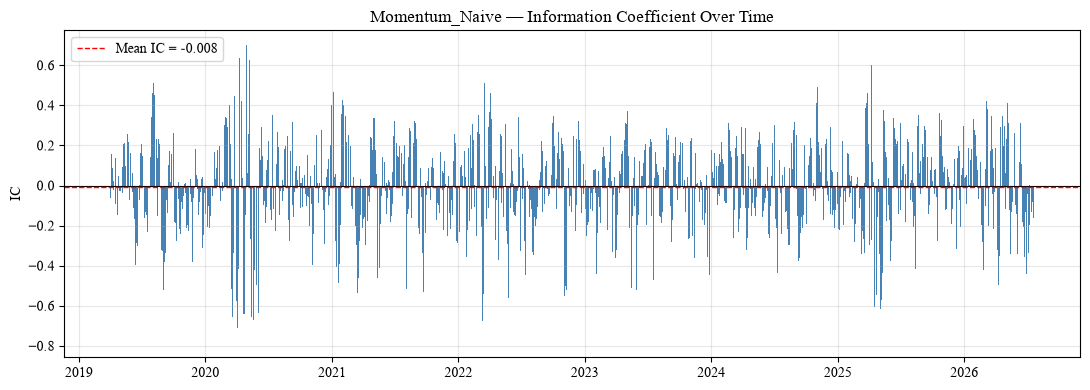

In [12]:
plot_ic_series(ic_series, "Momentum_Naive")

In [13]:
decay = compute_decay_curve(momentum_signal, close, horizons=range(1, 64))
decay.round(4)

1     0.0007
2    -0.0025
3    -0.0047
4    -0.0061
5    -0.0076
       ...  
59   -0.0167
60   -0.0163
61   -0.0158
62   -0.0153
63   -0.0147
Length: 63, dtype: float64

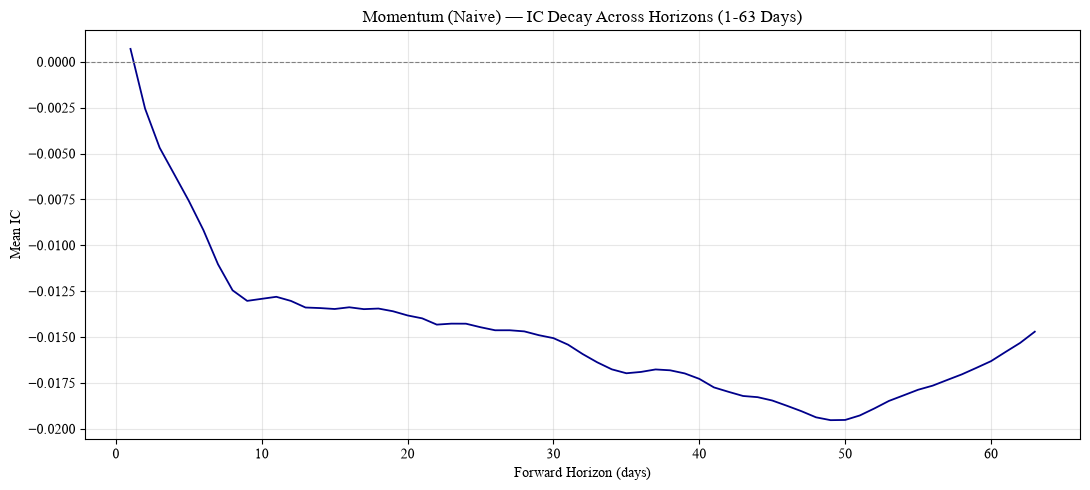

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(decay.index, decay.values, color="darkblue", linewidth=1.3)
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Momentum (Naive) — IC Decay Across Horizons (1-63 Days)")
ax.set_xlabel("Forward Horizon (days)")
ax.set_ylabel("Mean IC")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

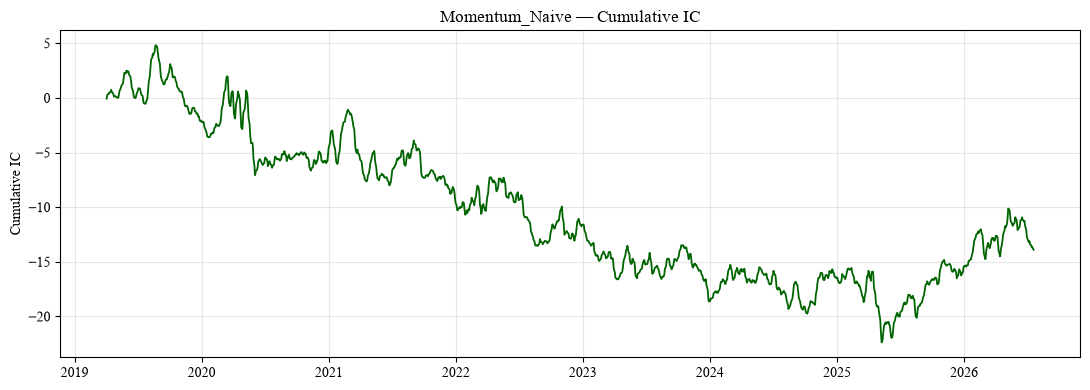

In [15]:
plot_cumulative_ic(ic_series, "Momentum_Naive")

In [16]:
import itertools
import pandas as pd

# Reasonable grid rather than every single value — full 1-by-1 combos
# across both dimensions would be extremely slow (thousands of Spearman
# calcs per combo). Stepping by 5 still covers the space well without
# taking hours to run.
lookback_range = range(5, 253, 5)   # ~5 days to ~1 year, step 5
horizon_range = range(1, 64, 5)      # 1 to 63 days, step 5

results = []

for lookback in lookback_range:
    signal = momentum_naive(close, lookback=lookback)

    for horizon in horizon_range:
        fwd_returns = compute_forward_returns(close, horizon=horizon)
        ic_series = compute_ic_series(signal, fwd_returns)

        if len(ic_series) < 10:  # not enough observations to trust
            continue

        results.append({
            "lookback": lookback,
            "horizon": horizon,
            "mean_ic": ic_series.mean(),
            "ic_std": ic_series.std(),
            "information_ratio": ic_series.mean() / ic_series.std() if ic_series.std() != 0 else 0,
            "n_obs": len(ic_series),
        })

results_df = pd.DataFrame(results).sort_values("mean_ic", ascending=False).reset_index(drop=True)

best = results_df.iloc[0]
print(f"Best combination is: lookback={int(best['lookback'])}, horizon={int(best['horizon'])}, "
      f"mean IC={best['mean_ic']:.4f}, IR={best['information_ratio']:.3f}")

results_df.head(10)

Best combination is: lookback=205, horizon=61, mean IC=0.0203, IR=0.111


,lookback,horizon,mean_ic,ic_std,information_ratio,n_obs
0,205,61,0.020320,0.182736,0.111199,1635
1,210,61,0.019779,0.183399,0.107849,1630
2,200,61,0.019754,0.182631,0.108161,1640
3,225,31,0.019559,0.204613,0.095589,1645
4,210,56,0.019545,0.187292,0.104356,1635
5,220,31,0.019518,0.204041,0.095656,1650
6,205,56,0.019472,0.186689,0.104301,1640
7,215,61,0.019074,0.185540,0.102801,1625
8,230,26,0.019024,0.206971,0.091917,1645
9,215,41,0.018962,0.197517,0.096000,1645


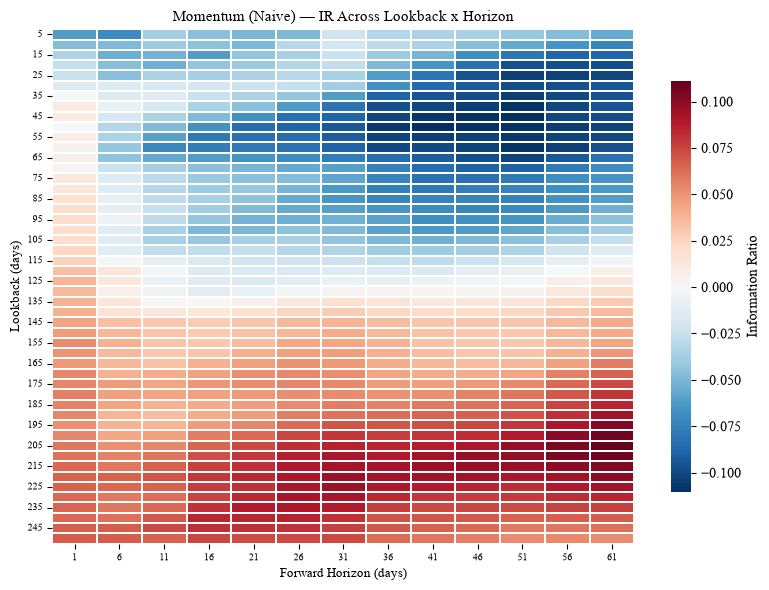

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

# Pivot into a lookback x horizon grid of information ratio
heatmap_data = results_df.pivot(index="lookback", columns="horizon", values="information_ratio")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    cmap="RdBu_r",
    center=0,
    annot=False,
    linewidths=0.1,
    cbar_kws={"label": "Information Ratio", "shrink": 0.8},
    ax=ax
)
ax.set_title("Momentum (Naive) — IR Across Lookback x Horizon", fontsize=11)
ax.set_xlabel("Forward Horizon (days)", fontsize=9)
ax.set_ylabel("Lookback (days)", fontsize=9)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

In [20]:
from src.signals import mean_reversion_naive

mr_signal = mean_reversion_naive(close)  # default lookback=5
mr_signal.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACN,ADBE,ADI,AEE,AEP,...,WST,WTW,WY,WYNN,XEL,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-21,0.017308,-0.040907,-0.053693,0.016651,-0.128382,-0.046819,-0.028898,0.025309,0.026649,0.033052,...,-0.004446,-0.000277,0.007983,0.013243,0.018087,0.037433,0.069604,0.023179,-0.008804,-0.024372
2026-07-22,0.009279,0.004916,-0.037647,0.056140,-0.126582,-0.022405,0.027610,0.010819,-0.005656,-0.004302,...,0.001643,-0.004875,0.003764,0.027615,-0.011861,0.043564,0.032772,0.016197,-0.029706,-0.002377
2026-07-23,-0.026745,0.034808,-0.009945,0.069215,-0.019427,0.040592,0.098338,0.000867,-0.001503,-0.013445,...,0.019203,0.020249,0.033129,0.013658,-0.009877,0.067279,0.031098,0.043733,0.030524,0.023666
2026-07-24,-0.054085,0.002157,-0.019136,0.033429,-0.023639,-0.023821,0.051170,0.009324,-0.019991,-0.025730,...,0.083854,-0.005725,0.022458,-0.002897,-0.036816,0.024678,-0.006760,-0.002524,0.027973,0.008944
2026-07-27,-0.058575,-0.031599,-0.013932,-0.013247,-0.027838,-0.064465,-0.012823,0.001530,-0.015305,-0.019382,...,0.059804,-0.031845,0.002087,-0.042233,-0.025931,0.003814,-0.002918,-0.026193,0.000378,-0.009449


In [21]:
print(f"Shape: {mr_signal.shape}")
print(f"Non-null values: {mr_signal.notna().sum().sum()}")
mr_signal.iloc[-1].describe()

Shape: (1901, 503)
Non-null values: 935032


count    503.000000
mean      -0.013278
std        0.043054
min       -0.250944
25%       -0.034406
50%       -0.011707
75%        0.008122
max        0.163298
Name: 2026-07-27 00:00:00, dtype: float64

In [22]:
HORIZON = 5

fwd_returns = compute_forward_returns(close, horizon=HORIZON)
mr_ic_series = compute_ic_series(mr_signal, fwd_returns)

print(pd.Series(summarize_ic(mr_ic_series)).round(4))

Mean IC                 0.0142
IC Std                  0.1920
Information Ratio       0.0742
% Positive IC           0.5156
N Observations       1891.0000
dtype: float64


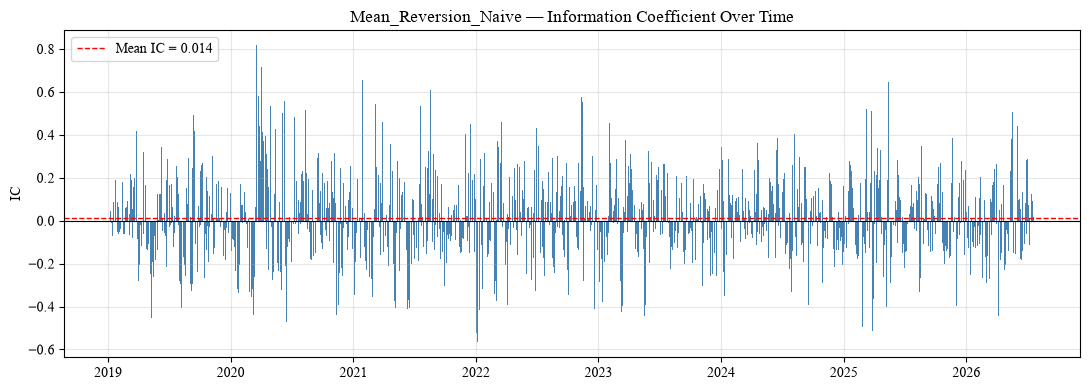

In [23]:
plot_ic_series(mr_ic_series, "Mean_Reversion_Naive")

In [24]:
mr_decay = compute_decay_curve(mr_signal, close, horizons=range(1, 64))
mr_decay.round(4)

1     0.0128
2     0.0147
3     0.0154
4     0.0151
5     0.0142
       ...  
59    0.0096
60    0.0097
61    0.0094
62    0.0096
63    0.0095
Length: 63, dtype: float64

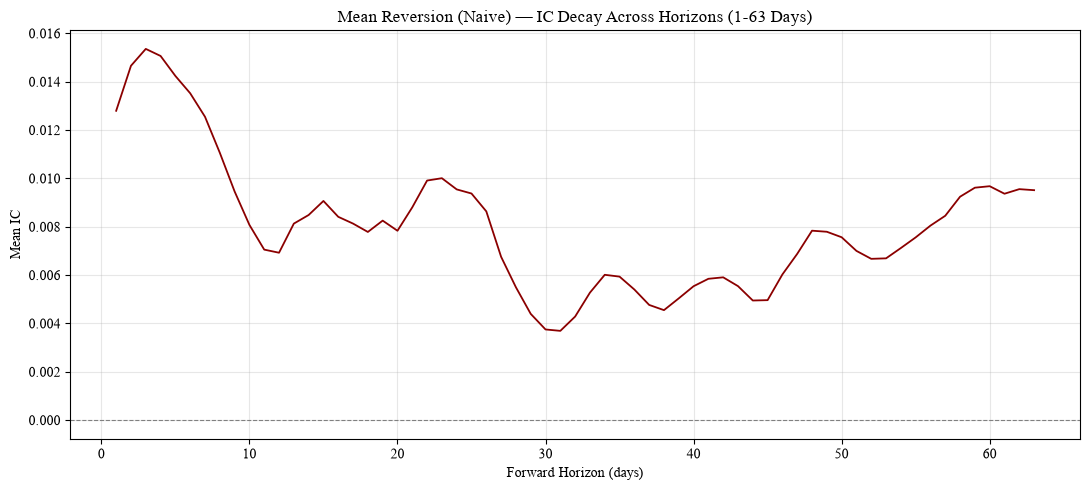

In [25]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(mr_decay.index, mr_decay.values, color="darkred", linewidth=1.3)
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Mean Reversion (Naive) — IC Decay Across Horizons (1-63 Days)")
ax.set_xlabel("Forward Horizon (days)")
ax.set_ylabel("Mean IC")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

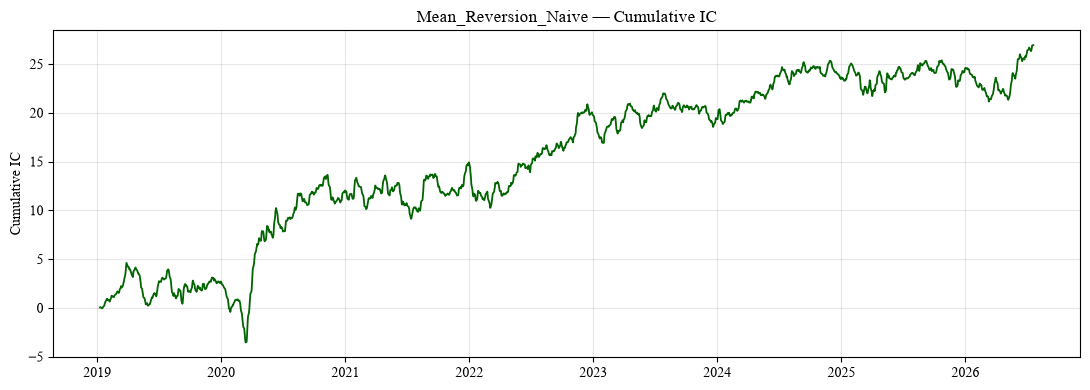

In [26]:
plot_cumulative_ic(mr_ic_series, "Mean_Reversion_Naive")

In [27]:
from src.signals import mean_reversion_naive

lookback_range = range(2, 63, 2)   # shorter range makes sense for reversal — 2 to ~63 days
horizon_range = range(1, 64, 5)

mr_results = []

for lookback in lookback_range:
    signal = mean_reversion_naive(close, lookback=lookback)

    for horizon in horizon_range:
        fwd_returns = compute_forward_returns(close, horizon=horizon)
        ic_series = compute_ic_series(signal, fwd_returns)

        if len(ic_series) < 10:
            continue

        mr_results.append({
            "lookback": lookback,
            "horizon": horizon,
            "mean_ic": ic_series.mean(),
            "ic_std": ic_series.std(),
            "information_ratio": ic_series.mean() / ic_series.std() if ic_series.std() != 0 else 0,
            "n_obs": len(ic_series),
        })

mr_results_df = pd.DataFrame(mr_results).sort_values("mean_ic", ascending=False).reset_index(drop=True)

best_mr = mr_results_df.iloc[0]
print(f"Best combination is: lookback={int(best_mr['lookback'])}, horizon={int(best_mr['horizon'])}, "
      f"mean IC={best_mr['mean_ic']:.4f}, IR={best_mr['information_ratio']:.3f}")

mr_results_df.head(10)

Best combination is: lookback=48, horizon=41, mean IC=0.0201, IR=0.111


,lookback,horizon,mean_ic,ic_std,information_ratio,n_obs
0,48,41,0.020110,0.180850,0.111198,1812
1,50,41,0.020060,0.181497,0.110523,1810
2,50,46,0.020054,0.181623,0.110416,1805
3,48,46,0.020041,0.181502,0.110420,1807
4,46,51,0.019861,0.178706,0.111140,1804
5,48,51,0.019832,0.179494,0.110491,1802
6,60,51,0.019822,0.182405,0.108672,1790
7,46,46,0.019806,0.181186,0.109312,1809
8,58,51,0.019754,0.182380,0.108313,1792
9,50,51,0.019722,0.180211,0.109438,1800


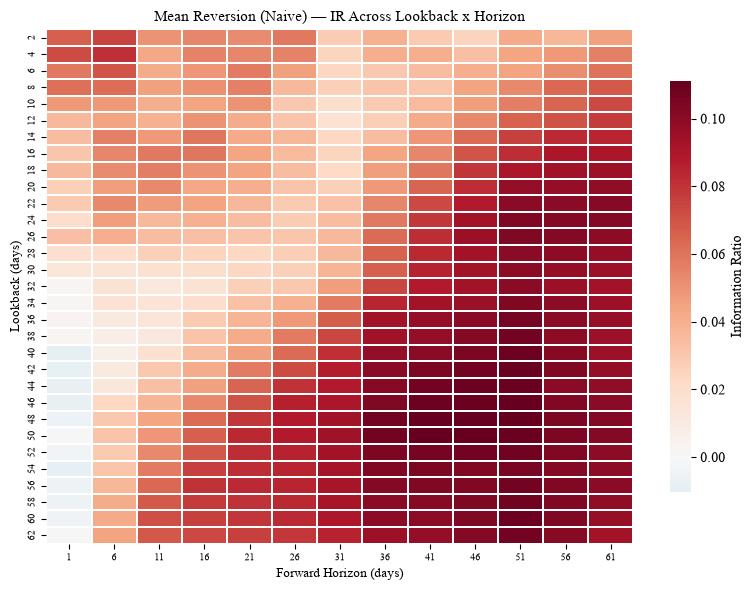

In [28]:
mr_heatmap_data = mr_results_df.pivot(index="lookback", columns="horizon", values="information_ratio")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    mr_heatmap_data,
    cmap="RdBu_r",
    center=0,
    annot=False,
    linewidths=0.1,
    cbar_kws={"label": "Information Ratio", "shrink": 0.8},
    ax=ax
)
ax.set_title("Mean Reversion (Naive) — IR Across Lookback x Horizon", fontsize=11)
ax.set_xlabel("Forward Horizon (days)", fontsize=9)
ax.set_ylabel("Lookback (days)", fontsize=9)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

In [29]:
# Momentum at roughly the same lookback/horizon as reversal's hot zone
momentum_at_cell = results_df[(results_df["lookback"] == 45) & (results_df["horizon"] == 41)]
print("Momentum at ~45/41:")
print(momentum_at_cell)

mr_at_cell = mr_results_df[(mr_results_df["lookback"] == 44) & (mr_results_df["horizon"] == 41)]
print("\nMean Reversion at ~44/41:")
print(mr_at_cell)

Momentum at ~45/41:
     lookback  horizon   mean_ic    ic_std  information_ratio  n_obs
641        45       41 -0.019323  0.180213          -0.107222   1815

Mean Reversion at ~44/41:
    lookback  horizon   mean_ic    ic_std  information_ratio  n_obs
25        44       41  0.019189  0.180033           0.106588   1816


<div style="font-family: 'Helvetica Neue', sans-serif;">

##### *Takeaway:*
What this is really telling you: at the 40-50 day timescale specifically, this particular signal construction (trailing return over that window) is mean-reverting, not trend-following — recent losers over that horizon tend to bounce, recent winners tend to give some back. Momentum's negative IR in this exact zone and reversal's positive IR are mathematically almost the same statement, since reversal is quite literally the negative of the momentum calculation at the same lookback.

</div>

In [30]:
best_momentum = results_df.iloc[0]
MOMENTUM_LOOKBACK, MOMENTUM_HORIZON = int(best_momentum["lookback"]), int(best_momentum["horizon"])
print(f"Momentum best: lookback={MOMENTUM_LOOKBACK}, horizon={MOMENTUM_HORIZON}, "
      f"mean_ic={best_momentum['mean_ic']:.4f}")

best_mr = mr_results_df.iloc[0]
MR_LOOKBACK, MR_HORIZON = int(best_mr["lookback"]), int(best_mr["horizon"])
print(f"Mean Reversion best: lookback={MR_LOOKBACK}, horizon={MR_HORIZON}, "
      f"mean_ic={best_mr['mean_ic']:.4f}")

Momentum best: lookback=205, horizon=61, mean_ic=0.0203
Mean Reversion best: lookback=48, horizon=41, mean_ic=0.0201


In [31]:
from src.evaluation import compute_ic_by_sector
from src.visualize import plot_ic_by_sector

momentum_best_signal = momentum_naive(close, lookback=MOMENTUM_LOOKBACK)
momentum_by_sector = compute_ic_by_sector(momentum_best_signal, close, universe, horizon=MOMENTUM_HORIZON)
momentum_by_sector.round(4)

,mean_ic,n_stocks
Information Technology,0.0292,74.0
Materials,0.0283,26.0
Industrials,0.0271,81.0
Communication Services,0.0199,23.0
Consumer Discretionary,0.0196,47.0
Financials,0.0121,76.0
Real Estate,-0.0000,31.0
Energy,-0.0056,21.0
Consumer Staples,-0.0057,34.0
Utilities,-0.0214,31.0


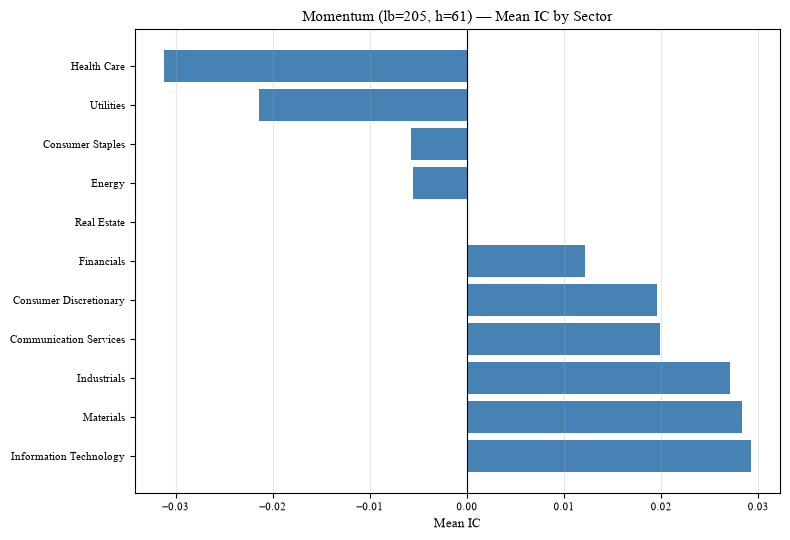

In [32]:
plot_ic_by_sector(momentum_by_sector, f"Momentum (lb={MOMENTUM_LOOKBACK}, h={MOMENTUM_HORIZON})", color="steelblue")

In [33]:
mr_best_signal = mean_reversion_naive(close, lookback=MR_LOOKBACK)
mr_by_sector = compute_ic_by_sector(mr_best_signal, close, universe, horizon=MR_HORIZON)
mr_by_sector.round(4)

,mean_ic,n_stocks
Consumer Discretionary,0.0537,47.0
Utilities,0.0319,31.0
Consumer Staples,0.0311,34.0
Health Care,0.0273,59.0
Financials,0.0218,76.0
Energy,0.0126,21.0
Communication Services,0.0084,23.0
Industrials,0.0028,81.0
Materials,0.0015,26.0
Real Estate,-0.0045,31.0


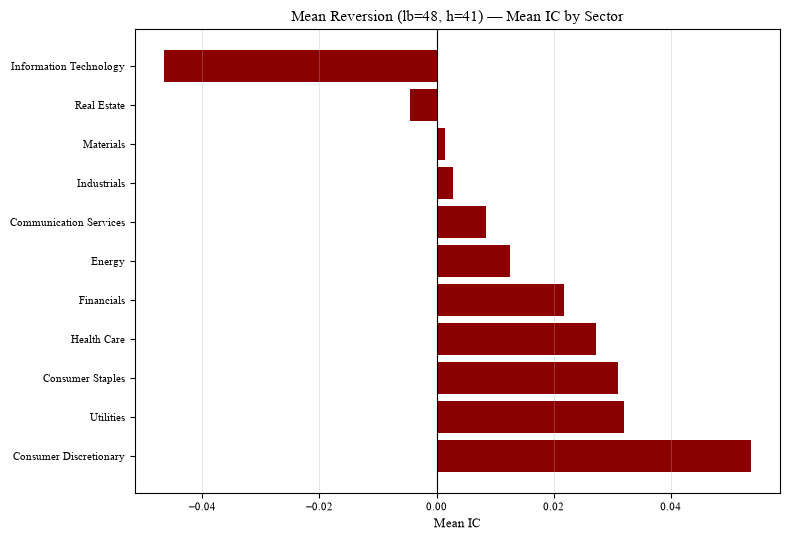

In [34]:
plot_ic_by_sector(mr_by_sector, f"Mean Reversion (lb={MR_LOOKBACK}, h={MR_HORIZON})", color="darkred")

<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Momentum vs. Mean Reversion: A Sector Split

Breaking each signal's best-performing combo down by sector reveals an interesting pattern: momentum and reversal are almost perfectly inversely related, sector by sector.

- ***Tech, Materials, Industrials*** — momentum's strongest sectors, reversal's weakest (Tech: momentum +0.029, reversal -0.047)
- ***Health Care, Utilities, Consumer Staples*** — reversal's strongest sectors, momentum's weakest (Health Care: reversal +0.027, momentum -0.031)

---
*Why this makes sense:* Tech/Materials/Industrials are driven by slow-diffusing fundamental information (product cycles, guidance revisions, secular themes), namely the setup where trends plausibly continue. Health Care/Utilities/Staples are more defensive and rate/sentiment-sensitive, with price moves more likely to be short-term overreactions that correct, i.e. the setup where reversal wins.

*Takeaway:* blending momentum and reversal uniformly across the whole universe mutes both signals, since they're actively working against each other in different sectors. A sector-conditional composite — momentum-weighted where momentum wins, reversal-weighted where reversal wins — is a natural next step.

*Caveat:* smaller sectors (Materials, Real Estate, Comm. Services, Energy — all under 30 stocks) have noisier IC estimates due to sample size; the Tech/Health Care/Industrials/Financials results are the ones to weight most heavily.

</div>

In [36]:
MOMENTUM_SECTORS = ["Information Technology", "Materials", "Industrials"]
REVERSAL_SECTORS = ["Consumer Discretionary", "Utilities", "Consumer Staples", "Health Care"]

composite_signal = momentum_reversion_sector_conditional_naive(
    close, universe,
    momentum_sectors=MOMENTUM_SECTORS,
    reversal_sectors=REVERSAL_SECTORS,
    momentum_lookback=MOMENTUM_LOOKBACK,   # 205, from earlier grid search
    reversal_lookback=MR_LOOKBACK,          # 48, from earlier grid search
)

composite_signal.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACN,ADBE,ADI,AEE,AEP,...,WST,WTW,WY,WYNN,XEL,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-21,-0.194290,0.302632,-0.271935,-0.051441,-0.215854,-0.398684,-0.356979,0.554324,-0.006591,0.001683,...,-0.114614,NaN,NaN,0.045199,0.015959,-0.164497,0.015968,-0.120335,-0.149378,0.010366
2026-07-22,-0.184382,0.272285,-0.227283,-0.033732,-0.200798,-0.385205,-0.383443,0.577091,-0.030227,-0.008565,...,-0.148492,NaN,NaN,0.027065,-0.011199,-0.170579,0.029882,-0.066518,-0.129880,0.029020
2026-07-23,-0.241873,0.262703,-0.241001,-0.034594,-0.210409,-0.407461,-0.411244,0.550274,-0.045636,-0.054474,...,-0.175529,NaN,NaN,-0.008463,-0.018385,-0.174586,0.011209,-0.086656,-0.142843,-0.010086
2026-07-24,-0.225821,0.312589,-0.239294,-0.055585,-0.222557,-0.392636,-0.373685,0.533425,-0.045456,-0.053966,...,-0.093308,NaN,NaN,-0.018281,-0.028189,-0.159651,0.006514,-0.108200,-0.124613,-0.005237
2026-07-27,-0.236842,0.326879,-0.229805,-0.105457,-0.245830,-0.362390,-0.326010,0.527869,-0.061492,-0.067439,...,-0.093631,NaN,NaN,-0.047599,-0.043618,-0.177068,0.009647,-0.102923,-0.109604,-0.043603


In [37]:
non_null_tickers = composite_signal.dropna(axis=1, how="all").columns.tolist()
print(f"Tickers included in composite: {len(non_null_tickers)} out of {len(composite_signal.columns)}")
# Should roughly match the combined stock count of your momentum + reversal sectors

Tickers included in composite: 349 out of 503


In [38]:
COMPOSITE_HORIZON = 50

fwd_returns_composite = compute_forward_returns(close, horizon=COMPOSITE_HORIZON)
composite_ic = compute_ic_series(composite_signal, fwd_returns_composite)

print(pd.Series(summarize_ic(composite_ic)).round(4))

Mean IC                 0.0483
IC Std                  0.1415
Information Ratio       0.3415
% Positive IC           0.6112
N Observations       1803.0000
dtype: float64


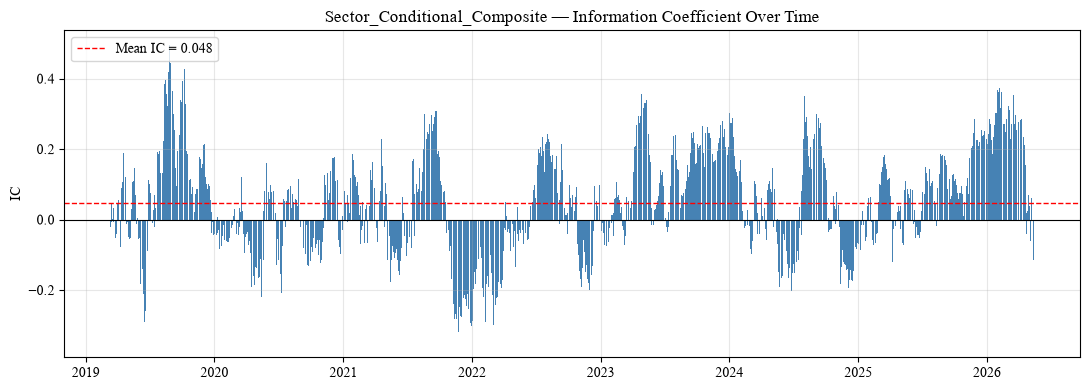

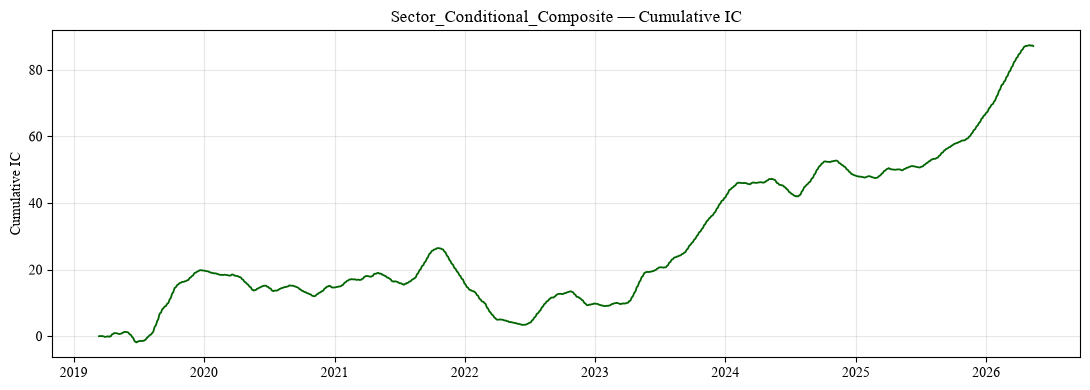

In [39]:
plot_ic_series(composite_ic, "Sector_Conditional_Composite")
plot_cumulative_ic(composite_ic, "Sector_Conditional_Composite")

In [40]:
# Recompute momentum and reversal's full-universe IC at the SAME horizon (50)
# so this is an apples-to-apples comparison against the composite
momentum_signal_50 = momentum_naive(close, lookback=MOMENTUM_LOOKBACK)
momentum_ic_50 = compute_ic_series(momentum_signal_50, fwd_returns_composite)

mr_signal_50 = mean_reversion_naive(close, lookback=MR_LOOKBACK)
mr_ic_50 = compute_ic_series(mr_signal_50, fwd_returns_composite)

comparison = pd.DataFrame({
    "Momentum (full universe)": pd.Series(summarize_ic(momentum_ic_50)),
    "Mean Reversion (full universe)": pd.Series(summarize_ic(mr_ic_50)),
    "Sector-Conditional Composite": pd.Series(summarize_ic(composite_ic)),
})

comparison.round(4)

,Momentum (full universe),Mean Reversion (full universe),Sector-Conditional Composite
Mean IC,0.0182,0.0203,0.0483
IC Std,0.1917,0.1800,0.1415
Information Ratio,0.0948,0.1128,0.3415
% Positive IC,0.6021,0.5324,0.6112
N Observations,1646.0000,1803.0000,1803.0000


<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### The Sector-Conditional Composite: Good News, Bad News

***The good news:*** the composite signal is a clear, decisive improvement over either naive signal alone across the board. Mean IC nearly triples momentum's and more than doubles reversal's (0.048 vs. 0.018 / 0.020), the Information Ratio jumps roughly 3x (0.34 vs. ~0.10-0.11), and IC volatility actually *decreases* rather than averaging out, a sign the sector split is removing noise rather than just blending two mediocre signals together. This is a coherent, economically motivated result: momentum and reversal were shown to work in almost perfectly opposite sectors, and hence encoding that directly into the signal produced a stronger, more stable edge than either component achieves on its own.

***The bad news:*** this is still a full-sample result, which means it's vulnerable to the exact kind of hindsight bias we've flagged throughout this project. The sector groupings (which sectors get momentum vs. reversal), the lookback windows (205 and 48 days), and the evaluation horizon (50 days) were all chosen by looking at performance across the entire historical dataset — the same data being used to validate the result. Nothing here has been tested walk-forward yet, so we don't actually know whether this composite would have been discoverable and usable in real time, or whether it's an artifact of fitting these specific choices to this specific stretch of market history.

---
***Bottom line:*** a strong, well-motivated finding, but not yet a validated one. The next step is rebuilding this with sector weights and lookbacks derived only from training data and testing only on unseen data.

</div>

In [41]:
from src.combination import walk_forward_sector_conditional_composite

oos_ic, regime_log = walk_forward_sector_conditional_composite(
    close, universe,
    momentum_lookback=MOMENTUM_LOOKBACK,
    reversal_lookback=MR_LOOKBACK,
    horizon=50,
    train_years=2,
    test_months=6,
)

print(pd.Series(summarize_ic(oos_ic)).round(4))

Mean IC                 0.0232
IC Std                  0.1637
Information Ratio       0.1420
% Positive IC           0.5533
N Observations       1352.0000
dtype: float64


In [42]:
# See how sector assignments actually shifted window to window —
# genuinely interesting on its own, and a good robustness check
regime_log

,test_start,test_end,momentum_sectors,reversal_sectors
0,2021-01-02,2021-07-02,"[Industrials, Utilities, Consumer Discretionar...","[Health Care, Information Technology, Consumer..."
1,2021-07-02,2022-01-02,[],"[Industrials, Health Care, Information Technol..."
2,2022-01-02,2022-07-02,[Real Estate],"[Industrials, Health Care, Information Technol..."
3,2022-07-02,2023-01-02,[],"[Industrials, Health Care, Information Technol..."
4,2023-01-02,2023-07-02,[],"[Industrials, Health Care, Information Technol..."
5,2023-07-02,2024-01-02,[],"[Industrials, Health Care, Information Technol..."
6,2024-01-02,2024-07-02,[],"[Industrials, Health Care, Information Technol..."
7,2024-07-02,2025-01-02,[],"[Industrials, Health Care, Information Technol..."
8,2025-01-02,2025-07-02,"[Materials, Energy]","[Industrials, Health Care, Utilities, Financia..."
9,2025-07-02,2026-01-02,[Materials],"[Industrials, Health Care, Utilities, Financia..."


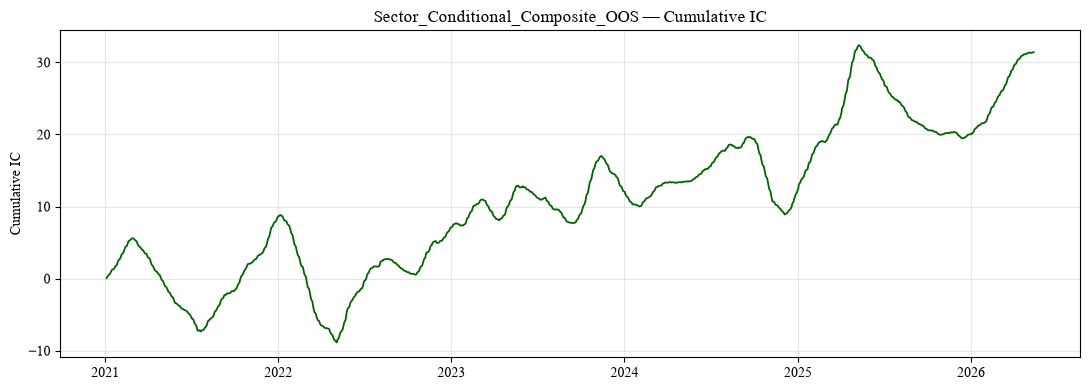

In [43]:
plot_cumulative_ic(oos_ic, "Sector_Conditional_Composite_OOS")

<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Expanding vs. Rolling Windows

The walk-forward results above use an *expanding* training window: training data only grows over time, never dropping old history. This makes sector regime detection slow to react to genuine shifts, since years of older data can outweigh a real recent change.

A *rolling* window instead keeps training data a fixed length, dropping old data as new data comes in — always looking at "the most recent N years" rather than the full history. This should react faster to real regime changes, at the cost of noisier, less stable estimates from having less data per window.

Given how much sector assignment shifted over time in the expanding version, worth testing whether a rolling window tells a cleaner, more responsive story.

</div>

In [45]:
# Expanding (default, already have this)
oos_ic_expanding, regime_log_expanding = walk_forward_sector_conditional_composite(
    close, universe,
    momentum_lookback=MOMENTUM_LOOKBACK,
    reversal_lookback=MR_LOOKBACK,
    horizon=50,
    train_years=2,
    test_months=6,
    expanding=True,
)

# Rolling
oos_ic_rolling, regime_log_rolling = walk_forward_sector_conditional_composite(
    close, universe,
    momentum_lookback=MOMENTUM_LOOKBACK,
    reversal_lookback=MR_LOOKBACK,
    horizon=50,
    train_years=2,
    test_months=6,
    expanding=False,
)

comparison = pd.DataFrame({
    "Expanding Window": pd.Series(summarize_ic(oos_ic_expanding)),
    "Rolling Window": pd.Series(summarize_ic(oos_ic_rolling)),
})
comparison.round(4)

,Expanding Window,Rolling Window
Mean IC,0.0232,0.0359
IC Std,0.1637,0.1529
Information Ratio,0.1420,0.2346
% Positive IC,0.5533,0.6065
N Observations,1352.0000,1352.0000


In [46]:
regime_log_rolling

,test_start,test_end,momentum_sectors,reversal_sectors
0,2021-01-02,2021-07-02,"[Industrials, Utilities, Consumer Discretionar...","[Health Care, Information Technology, Consumer..."
1,2021-07-02,2022-01-02,[],"[Industrials, Health Care, Information Technol..."
2,2022-01-02,2022-07-02,[Real Estate],"[Industrials, Health Care, Information Technol..."
3,2022-07-02,2023-01-02,[],"[Industrials, Information Technology, Utilitie..."
4,2023-01-02,2023-07-02,[],"[Industrials, Health Care, Information Technol..."
5,2023-07-02,2024-01-02,[],"[Industrials, Health Care, Utilities, Financia..."
6,2024-01-02,2024-07-02,"[Industrials, Information Technology, Utilitie...","[Health Care, Financials, Consumer Discretiona..."
7,2024-07-02,2025-01-02,"[Industrials, Information Technology, Utilitie...","[Health Care, Financials, Real Estate, Energy]"
8,2025-01-02,2025-07-02,"[Industrials, Information Technology, Utilitie...","[Health Care, Financials]"
9,2025-07-02,2026-01-02,"[Industrials, Information Technology, Material...","[Health Care, Utilities, Financials, Real Esta..."


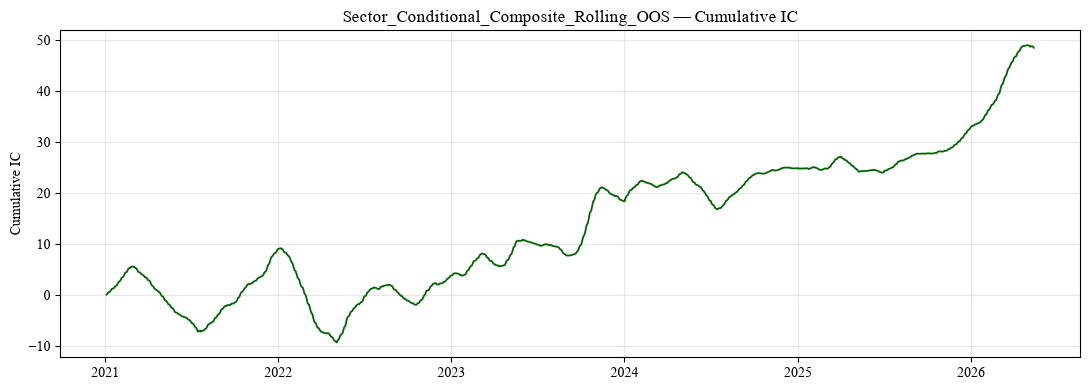

In [47]:
plot_cumulative_ic(oos_ic_rolling, "Sector_Conditional_Composite_Rolling_OOS")

<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Rolling Window: Results

Switching from an expanding to a rolling training window improved every metric: Mean IC (0.036 vs. 0.023), IC volatility (lower), Information Ratio (0.235 vs. 0.142), and hit rate (61% vs. 55%).

The regime log explains why. The expanding window was slow to recognize that Information Technology and Industrials shifted from reversal-favoring to momentum-favoring. It didn't catch the flip until near the very end of the sample. The rolling window picked up the same shift roughly a year earlier, right around when it happened (early-to-mid 2024, coinciding with the AI-driven tech rally), and held that assignment consistently from then on.

Health Care stayed in the reversal bucket across almost the entire period under both window types, a sign that one is a stable, structural relationship, while Tech/Industrials look more like a real regime shift that a responsive window is better equipped to catch.

*Takeaway:* letting old, stale history drop out of the training set (rather than accumulating forever) significantly improves the signal's performance and its ability to track ongoing shifts in market regime.

</div>

<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Putting the Numbers in Perspective

It's worth being honest about scale here, since 0.02-0.05 IC can sound unimpressive next to, say, an R² from a regression class. In cross-sectional equity signal research, it isn't.

___
***Rough industry-accepted benchmarks for daily/short-horizon cross-sectional signals:***

- ***Mean IC of 0.02-0.05*** — considered a useful, tradeable signal. Grinold and Kahn's classic "Fundamental Law of Active Management" framework, widely used as a reference point in the industry, treats an IC around 0.05 as a *strong* individual signal.
- ***IC above 0.10*** — rare for a single raw signal at the individual-stock level. Generally, when research claims numbers above this on a single factor, it's usually a sign of overfitting, a data leak, or a very short/cherry-picked sample rather than a real, durable edge.
- ***Information Ratio of 0.5+*** — considered quite strong for a single signal. Many production signals at real funds run in the 0.1-0.3 range and are still very much worth trading, especially once combined with several other equally modest signals.

___
***Why the bar is so low compared to intuition:*** predicting stock returns is fighting one of the most competitive, well-studied, heavily-arbitraged prediction problems that exists. Thousands of well-resourced funds are already hunting for exactly this kind of edge. A small, consistent statistical advantage, correctly sized, combined with other small edges, and executed at scale across thousands of trades is what real quant edges actually look like. Nobody is finding a single signal with 0.3+ IC that isn't already priced away or overfit.

***The actual target going forward isn't "find one signal with a huge IC"*** — it's building a *set* of several modest, ideally uncorrelated signals (IC 0.02-0.05 each) that combine into something with a higher blended IR; this is the same logic that motivated our sector-conditional composite in the first place.

</div>

In [48]:
from src.signals import extreme_drawdown_bounce_naive

drawdown_signal = extreme_drawdown_bounce_naive(close, drawdown_window=3, vol_lookback_days=20, threshold_std=2.0)

# Sanity check: how often does this actually flag anything?
flagged_pct = (drawdown_signal != 0).sum().sum() / drawdown_signal.notna().sum().sum()
print(f"Percent of stock-days flagged as extreme drawdown: {flagged_pct:.2%}")
drawdown_signal.tail()

Percent of stock-days flagged as extreme drawdown: 2.41%


Ticker,A,AAPL,ABBV,ABNB,ABT,ACN,ADBE,ADI,AEE,AEP,...,WST,WTW,WY,WYNN,XEL,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-21,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.142343,0.0,0.0,0.0,0.0
2026-07-22,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2026-07-23,0.0,0.0,0.0,0.0,0.0,0.0,0.011702,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2026-07-24,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.349857,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2026-07-27,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.070920,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


In [50]:
from src.evaluation import compute_event_study_returns

event_returns = compute_event_study_returns(drawdown_signal, close, horizon=5)

print(f"Number of flagged events: {len(event_returns)}")
print(f"Mean forward return after flagged event: {event_returns.mean():.4f}")
print(f"Median forward return: {event_returns.median():.4f}")
print(f"% positive: {(event_returns > 0).mean():.2%}")

Number of flagged events: 935032
Mean forward return after flagged event: 0.0039
Median forward return: 0.0040
% positive: 54.62%


In [51]:
baseline_returns = compute_forward_returns(close, horizon=5).stack()
print(f"Baseline (unconditional) mean 5-day forward return: {baseline_returns.mean():.4f}")

Baseline (unconditional) mean 5-day forward return: 0.0039


In [52]:
import itertools

drawdown_windows = range(1, 6)               # 1 to 5 days
threshold_stds = [1.5, 2.0, 2.5, 3.0, 3.5]     # sigma thresholds
horizons = [1, 5, 10, 20, 30, 40]              # forward return horizons

# Precompute baseline (unconditional) mean return per horizon once,
# since it doesn't depend on the signal parameters
baseline_by_horizon = {}
for h in horizons:
    baseline_by_horizon[h] = compute_forward_returns(close, horizon=h).stack().mean()

grid_results = []

for window in drawdown_windows:
    for threshold in threshold_stds:
        signal = extreme_drawdown_bounce_naive(
            close, drawdown_window=window, vol_lookback_days=20, threshold_std=threshold
        )

        n_flagged = (signal != 0).sum().sum()
        if n_flagged < 30:  # too few events to trust any statistic
            continue

        for horizon in horizons:
            event_returns = compute_event_study_returns(signal, close, horizon=horizon)

            if len(event_returns) < 20:
                continue

            grid_results.append({
                "drawdown_window": window,
                "threshold_std": threshold,
                "horizon": horizon,
                "n_events": len(event_returns),
                "mean_event_return": event_returns.mean(),
                "median_event_return": event_returns.median(),
                "pct_positive": (event_returns > 0).mean(),
                "baseline_return": baseline_by_horizon[horizon],
                "excess_return": event_returns.mean() - baseline_by_horizon[horizon],
            })

grid_df = pd.DataFrame(grid_results).sort_values("excess_return", ascending=False).reset_index(drop=True)

best = grid_df.iloc[0]
print(f"Best combination is: drawdown_window={int(best['drawdown_window'])}, "
      f"threshold_std={best['threshold_std']}, horizon={int(best['horizon'])}, "
      f"excess_return={best['excess_return']:.4f}, n_events={int(best['n_events'])}")

grid_df.head(10)

Best combination is: drawdown_window=3, threshold_std=3.5, horizon=30, excess_return=0.0000, n_events=922458


,drawdown_window,threshold_std,horizon,n_events,mean_event_return,median_event_return,pct_positive,baseline_return,excess_return
0,3,3.5,30,922458,0.022482,0.019359,0.582571,0.022482,3.469447e-18
1,1,2.5,30,922458,0.022482,0.019359,0.582571,0.022482,3.469447e-18
2,2,2.0,30,922458,0.022482,0.019359,0.582571,0.022482,3.469447e-18
3,2,1.5,30,922458,0.022482,0.019359,0.582571,0.022482,3.469447e-18
4,2,2.5,30,922458,0.022482,0.019359,0.582571,0.022482,3.469447e-18
5,4,3.5,30,922458,0.022482,0.019359,0.582571,0.022482,3.469447e-18
6,5,2.0,30,922458,0.022482,0.019359,0.582571,0.022482,3.469447e-18
7,1,3.5,30,922458,0.022482,0.019359,0.582571,0.022482,3.469447e-18
8,2,3.0,30,922458,0.022482,0.019359,0.582571,0.022482,3.469447e-18
9,4,3.0,30,922458,0.022482,0.019359,0.582571,0.022482,3.469447e-18


### Macro Signals

In [57]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.fetch_data import get_sp500_universe, fetch_universe_prices, START_DATE, END_DATE
from src.fetch_macro_data import fetch_macro_series, MACRO_SERIES
from src.signals import rate_sensitivity_naive, evaluate_rate_sensitivity
from src.evaluation import compute_forward_returns, compute_ic_series, summarize_ic
from src.optimization import run_grid_search_parallel
from src.visualize import plot_ic_series, plot_cumulative_ic

import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
universe = get_sp500_universe()
print(f"{len(universe)} tickers across {universe['Sector'].nunique()} sectors")

503 tickers across 11 sectors


In [59]:
close, volume = fetch_universe_prices(universe["Symbol"].tolist(), start=START_DATE, end=END_DATE)

failed_tickers = close.columns[close.isna().all()].tolist()
if failed_tickers:
    close = close.drop(columns=failed_tickers)
    volume = volume.drop(columns=failed_tickers)

print(f"Close shape: {close.shape}")
close.tail()

Fetching batch 1 / 13 (40 tickers)...


[*********************100%***********************]  40 of 40 completed


Fetching batch 2 / 13 (40 tickers)...


[*********************100%***********************]  40 of 40 completed


Fetching batch 3 / 13 (40 tickers)...


...

[*********************100%***********************]  40 of 40 completed


Fetching batch 13 / 13 (23 tickers)...


[*********************100%***********************]  23 of 23 completed


Close shape: (1901, 503)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACN,ADBE,ADI,AEE,AEP,...,WST,WTW,WY,WYNN,XEL,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-21,132.860001,327.739990,256.100006,144.100006,99.669998,140.860001,227.160004,382.809998,109.940002,130.479996,...,359.005493,288.820007,23.610001,94.629997,78.720001,117.000000,147.169998,88.919998,262.399994,75.349998
2026-07-22,133.460007,325.890015,253.300003,140.050003,100.570000,140.089996,218.360001,386.730011,112.010002,133.070007,...,358.176025,286.510010,23.820000,94.370003,80.190002,116.139999,147.570007,88.680000,262.750000,74.190002
2026-07-23,139.740005,321.660004,256.920013,137.570007,100.750000,138.740005,212.169998,380.200012,113.269997,134.919998,...,355.247955,288.369995,23.639999,96.769997,80.769997,116.870003,147.369995,89.650002,256.950012,74.570000
2026-07-24,138.570007,333.019989,259.359985,141.100006,103.059998,146.990005,225.110001,371.859985,113.779999,135.539993,...,327.985779,295.109985,23.940001,96.919998,81.669998,119.750000,148.919998,91.349998,259.920013,75.349998
2026-07-27,137.889999,336.910004,256.910004,146.860001,104.489998,154.059998,237.750000,371.890015,112.110001,133.589996,...,331.033752,302.640015,23.910000,99.699997,80.709999,120.160004,147.800003,92.070000,264.589996,76.919998


In [60]:
returns = close.pct_change()
returns.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACN,ADBE,ADI,AEE,AEP,...,WST,WTW,WY,WYNN,XEL,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-21,0.019960,0.003521,0.010735,-0.005795,-0.019575,-0.026739,-0.032291,0.027788,-0.004347,-0.004350,...,0.019641,-0.015274,-0.014608,-0.010767,0.000636,-0.030012,-0.001357,-0.008917,-0.008652,-0.011155
2026-07-22,0.004516,-0.005645,-0.010933,-0.028106,0.009030,-0.005466,-0.038739,0.010240,0.018828,0.019850,...,-0.002310,-0.007998,0.008894,-0.002747,0.018674,-0.007350,0.002718,-0.002699,0.001334,-0.015395
2026-07-23,0.047055,-0.012980,0.014291,-0.017708,0.001790,-0.009637,-0.028348,-0.016885,0.011249,0.013902,...,-0.008175,0.006492,-0.007557,0.025432,0.007233,0.006286,-0.001355,0.010938,-0.022074,0.005122
2026-07-24,-0.008373,0.035317,0.009497,0.025660,0.022928,0.059464,0.060989,-0.021936,0.004503,0.004595,...,-0.076741,0.023373,0.012690,0.001550,0.011143,0.024643,0.010518,0.018963,0.011559,0.010460
2026-07-27,-0.004907,0.011681,-0.009446,0.040822,0.013875,0.048098,0.056150,0.000081,-0.014677,-0.014387,...,0.009293,0.025516,-0.001253,0.028683,-0.011755,0.003424,-0.007521,0.007882,0.017967,0.020836


In [61]:
macro_df = fetch_macro_series(start=START_DATE)
macro_df.tail()

Fetching GDP (Gross Domestic Product)...
Fetching GDPC1 (Real GDP)...
Fetching INDPRO (Industrial Production Index)...
Fetching RSAFS (Retail Sales)...
Fetching CPIAUCSL (CPI (All Urban Consumers))...
Fetching CPILFESL (Core CPI)...
Fetching PCEPI (PCE Price Index)...
Fetching PCEPILFE (Core PCE Price Index)...
Fetching UNRATE (Unemployment Rate)...
Fetching PAYEMS (Nonfarm Payrolls)...
Fetching ICSA (Initial Jobless Claims)...
Fetching CIVPART (Labor Force Participation Rate)...
Fetching DGS2 (2-Year Treasury Yield)...
Fetching DGS10 (10-Year Treasury Yield)...
Fetching DGS30 (30-Year Treasury Yield)...
Fetching T10Y2Y (10Y-2Y Treasury Spread)...
Fetching FEDFUNDS (Effective Federal Funds Rate)...
Fetching BAMLH0A0HYM2 (High Yield Credit Spread)...
Fetching BAA10Y (Baa Corporate Bond Spread)...
Fetching NFCI (Chicago Fed National Financial Conditions Index)...
Fetching UMCSENT (U. Michigan Consumer Sentiment)...
Fetching VIXCLS (VIX)...
Fetching HOUST (Housing Starts)...
Fetching CSUS

,GDP,GDPC1,INDPRO,RSAFS,CPIAUCSL,CPILFESL,PCEPI,PCEPILFE,UNRATE,PAYEMS,...,FEDFUNDS,BAMLH0A0HYM2,BAA10Y,NFCI,UMCSENT,VIXCLS,HOUST,CSUSHPISA,M2SL,DTWEXBGS
2026-07-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.84,1.62,NaN,NaN,18.21,NaN,NaN,NaN,120.6247
2026-07-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.87,1.60,NaN,NaN,20.66,NaN,NaN,NaN,120.7892
2026-07-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.84,1.64,NaN,NaN,17.09,NaN,NaN,NaN,119.6753
2026-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.85,1.63,NaN,NaN,15.99,NaN,NaN,NaN,119.7034
2026-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.78,NaN,NaN,NaN,15.86,NaN,NaN,NaN,NaN


In [62]:
yield_10y = macro_df["DGS10"]
yield_10y.tail()

2026-07-28    4.61
2026-07-29    4.67
2026-07-30    4.68
2026-07-31    4.75
2026-08-03    4.70
Name: DGS10, dtype: float64

In [63]:
BETA_WINDOW = 60
YIELD_CHANGE_LOOKBACK = 5

rate_signal = rate_sensitivity_naive(
    returns, yield_10y,
    beta_window=BETA_WINDOW,
    yield_change_lookback=YIELD_CHANGE_LOOKBACK,
)
rate_signal.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACN,ADBE,ADI,AEE,AEP,...,WST,WTW,WY,WYNN,XEL,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-21,-0.011860,-0.003177,-0.000803,-0.005507,0.002891,0.012280,0.008456,-0.009636,-0.001421,-0.000496,...,-0.001055,0.009885,-0.011170,-0.006131,-0.003574,-0.008603,0.003579,0.000527,-0.004963,-0.003692
2026-07-22,-0.014546,-0.004556,-0.001891,-0.007558,0.003383,0.015332,0.010139,-0.011974,-0.001424,-0.000068,...,-0.001852,0.011769,-0.013585,-0.007617,-0.004008,-0.010974,0.004541,0.000240,-0.006211,-0.004507
2026-07-23,-0.021269,-0.008769,-0.003057,-0.013455,0.006140,0.023983,0.013876,-0.020715,-0.001455,0.000658,...,-0.004189,0.019341,-0.022032,-0.010894,-0.005957,-0.016422,0.005848,0.001573,-0.012567,-0.005944
2026-07-24,-0.020715,-0.009808,-0.003171,-0.014101,0.005366,0.021837,0.011696,-0.019743,-0.001595,0.000488,...,-0.001371,0.018484,-0.022295,-0.010993,-0.006268,-0.016795,0.005398,0.001794,-0.012695,-0.006435
2026-07-27,-0.002281,-0.001230,-0.000607,-0.002038,0.000918,0.002441,0.001255,-0.002676,-0.000064,0.000202,...,-0.000296,0.002299,-0.002627,-0.001354,-0.000667,-0.001948,0.000502,0.000542,-0.001484,-0.000756


In [64]:
print(f"Shape: {rate_signal.shape}")
print(f"Non-null values: {rate_signal.notna().sum().sum()}")
rate_signal.iloc[-1].describe()

Shape: (1901, 503)
Non-null values: 907357


count    501.000000
mean      -0.001323
std        0.002609
min       -0.012805
25%       -0.002770
50%       -0.000957
75%        0.000371
max        0.005041
Name: 2026-07-27 00:00:00, dtype: float64

In [65]:
HORIZON = 10

fwd_returns = compute_forward_returns(close, horizon=HORIZON)
rate_ic_series = compute_ic_series(rate_signal, fwd_returns)

print(pd.Series(summarize_ic(rate_ic_series)).round(4))

/Users/paulgrajzl/Documents/Quant-Projects/alpha-signal-research/src/evaluation.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, _ = spearmanr(sig_row[common], ret_row[common])


Mean IC                 0.0021
IC Std                  0.2518
Information Ratio       0.0083
% Positive IC           0.4768
N Observations       1831.0000
dtype: float64


In [66]:
# Check how much cross-sectional variation the signal actually has, day by day
daily_std = rate_signal.std(axis=1)
print(daily_std.describe())
print(f"\nNumber of near-zero-variance days: {(daily_std < 1e-6).sum()}")

count    1841.000000
mean        0.005330
std         0.004798
min         0.000000
25%         0.001828
50%         0.004082
75%         0.007505
max         0.043887
dtype: float64

Number of near-zero-variance days: 89


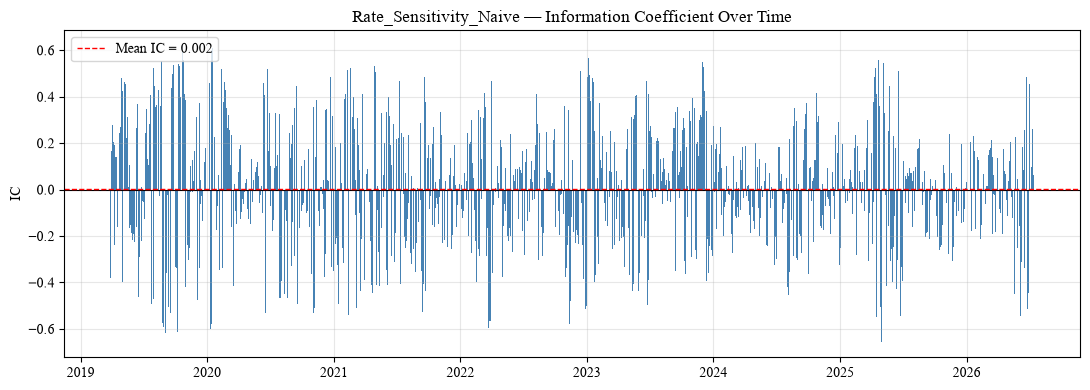

In [67]:
plot_ic_series(rate_ic_series, "Rate_Sensitivity_Naive")

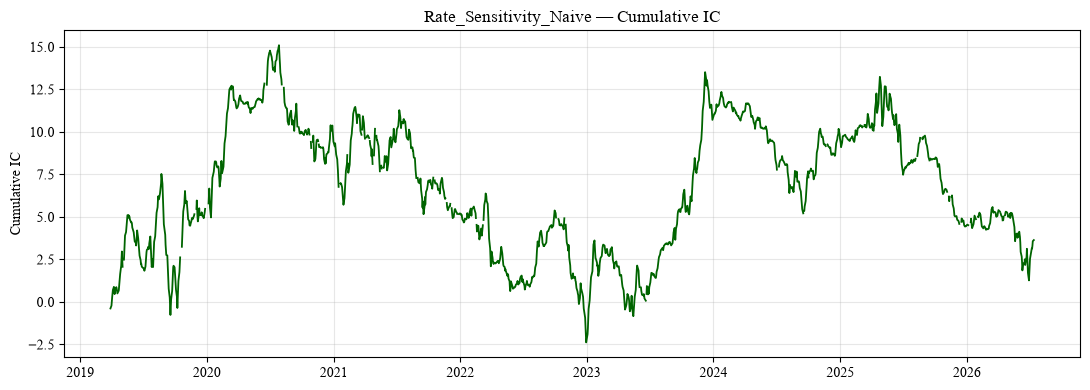

In [68]:
plot_cumulative_ic(rate_ic_series, "Rate_Sensitivity_Naive")

In [72]:
from skopt.space import Integer
from src.optimization import run_bayesian_optimization_parallel

search_space = [
    Integer(10, 250, name="beta_window"),
    Integer(1, 60, name="yield_change_lookback"),
    Integer(1, 60, name="horizon"),
]
param_names = ["beta_window", "yield_change_lookback", "horizon"]

bayes_results = run_bayesian_optimization_parallel(
    evaluate_rate_sensitivity,
    search_space,
    param_names,
    fixed_args={"returns": returns, "yield_10y": yield_10y, "close": close},
    n_calls=40,
    batch_size=6,
    metric="mean_ic",
    n_jobs=6,
)

print("\nTop 5 combinations:")
bayes_results.head(5)

Batch 1/7: evaluating 6 candidates...
Batch 2/7: evaluating 6 candidates...
Batch 3/7: evaluating 6 candidates...
Batch 4/7: evaluating 6 candidates...
Batch 5/7: evaluating 6 candidates...
Batch 6/7: evaluating 6 candidates...
Batch 7/7: evaluating 6 candidates...

Best mean_ic: 0.0458
Best parameters: {'beta_window': 139.0, 'yield_change_lookback': 45.0, 'horizon': 22.0}

Top 5 combinations:


,beta_window,yield_change_lookback,horizon,mean_ic,information_ratio,n_obs
0,139,45,22,0.045783,0.184505,1740
1,120,51,20,0.042430,0.168519,1761
2,147,47,17,0.040795,0.161005,1737
3,104,47,24,0.039138,0.156088,1773
4,126,53,18,0.036616,0.144931,1757


In [73]:
from src.evaluation import compute_ic_by_sector
from src.visualize import plot_ic_by_sector

BETA_WINDOW = 120
YIELD_CHANGE_LOOKBACK = 50
HORIZON = 20

rate_signal_test = rate_sensitivity_naive(
    returns, yield_10y,
    beta_window=BETA_WINDOW,
    yield_change_lookback=YIELD_CHANGE_LOOKBACK,
)

rate_by_sector = compute_ic_by_sector(rate_signal_test, close, universe, horizon=HORIZON)
rate_by_sector.round(4)

,mean_ic,n_stocks
Communication Services,0.0596,23.0
Energy,0.0593,21.0
Health Care,0.0538,59.0
Consumer Staples,0.0368,34.0
Utilities,0.0346,31.0
Materials,0.0336,26.0
Real Estate,0.0305,31.0
Industrials,0.0275,81.0
Information Technology,0.0257,74.0
Financials,0.0237,76.0


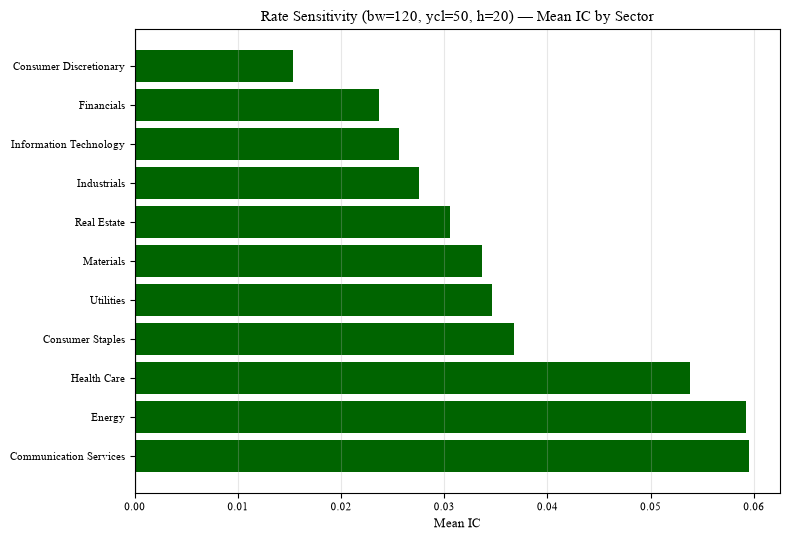

In [74]:
plot_ic_by_sector(rate_by_sector, f"Rate Sensitivity (bw={BETA_WINDOW}, ycl={YIELD_CHANGE_LOOKBACK}, h={HORIZON})", color="darkgreen")

In [75]:
def compute_rate_betas(returns, yield_10y, beta_window=120):
    """
    Computes just the rolling rate beta for every stock (without
    multiplying by the recent yield move), for direct inspection of
    each stock's/sector's sensitivity to 10Y yield changes.
    """
    daily_yield_change = yield_10y.diff()
    aligned_daily_change = daily_yield_change.reindex(returns.index).ffill()

    betas = pd.DataFrame(index=returns.index, columns=returns.columns, dtype=float)

    for ticker in returns.columns:
        stock_returns = returns[ticker]
        rolling_cov = stock_returns.rolling(beta_window).cov(aligned_daily_change)
        rolling_var = aligned_daily_change.rolling(beta_window).var()
        betas[ticker] = rolling_cov / rolling_var

    return betas


rate_betas = compute_rate_betas(returns, yield_10y, beta_window=120)
rate_betas.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACN,ADBE,ADI,AEE,AEP,...,WST,WTW,WY,WYNN,XEL,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-21,-0.071549,-0.018519,-0.054116,-0.070994,-0.026271,0.076825,0.060978,-0.103964,-0.047500,-0.036718,...,0.007502,0.055315,-0.109603,-0.062709,-0.061638,-0.066585,-0.006082,-0.045864,-0.084421,-0.065176
2026-07-22,-0.069558,-0.018980,-0.054052,-0.074597,-0.023417,0.077378,0.054633,-0.105215,-0.044310,-0.033517,...,0.008061,0.053917,-0.107303,-0.062221,-0.058359,-0.064958,-0.005580,-0.045893,-0.083306,-0.065259
2026-07-23,-0.062991,-0.020639,-0.051381,-0.076978,-0.023012,0.073547,0.048277,-0.107530,-0.042563,-0.031590,...,0.004582,0.055411,-0.108424,-0.061488,-0.057343,-0.061841,-0.004696,-0.043936,-0.085878,-0.063599
2026-07-24,-0.062269,-0.024017,-0.052751,-0.078073,-0.027217,0.066339,0.041572,-0.103348,-0.042483,-0.032107,...,0.013062,0.052750,-0.109214,-0.060793,-0.058308,-0.064316,-0.005762,-0.046422,-0.085891,-0.066787
2026-07-27,-0.062401,-0.027459,-0.052327,-0.082728,-0.028610,0.060198,0.035839,-0.104217,-0.040297,-0.029682,...,0.010826,0.050389,-0.109176,-0.064634,-0.055610,-0.065701,-0.005355,-0.046358,-0.089305,-0.069363


In [76]:
latest_betas = rate_betas.iloc[-1]  # most recent date's beta for every stock

sector_map = dict(zip(universe["Symbol"], universe["Sector"]))
beta_by_ticker = pd.DataFrame({
    "beta": latest_betas,
    "sector": [sector_map.get(t) for t in latest_betas.index],
}).dropna()

sector_beta_summary = beta_by_ticker.groupby("sector")["beta"].agg(["mean", "std", "count"]).sort_values("mean")
sector_beta_summary.round(4)

,mean,std,count
sector,,,
Consumer Discretionary,-0.0957,0.0728,47
Information Technology,-0.0911,0.1207,74
Industrials,-0.0911,0.0804,79
Materials,-0.0812,0.1172,26
Real Estate,-0.0723,0.0478,31
Utilities,-0.0501,0.0526,31
Health Care,-0.0482,0.0436,59
Communication Services,-0.0435,0.0723,23
Consumer Staples,-0.0258,0.0479,34


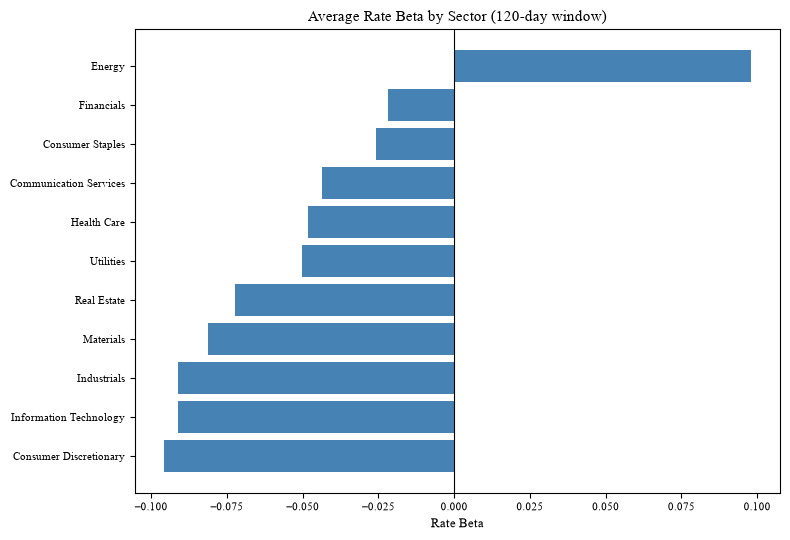

In [77]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(sector_beta_summary.index, sector_beta_summary["mean"], color="steelblue")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Average Rate Beta by Sector (120-day window)", fontsize=11)
ax.set_xlabel("Rate Beta", fontsize=9)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

In [78]:
def compute_sector_avg_beta_series(rate_betas, universe, lookback_days=252):
    """
    Computes the average rate beta per sector, for every date over the
    trailing lookback_days, by averaging the already-computed rolling
    betas across all stocks within each sector on each date.
    """
    sector_map = dict(zip(universe["Symbol"], universe["Sector"]))

    recent_betas = rate_betas.tail(lookback_days)

    sector_series = {}
    for sector in universe["Sector"].unique():
        sector_tickers = [t for t in recent_betas.columns if sector_map.get(t) == sector]
        if len(sector_tickers) < 3:
            continue
        sector_series[sector] = recent_betas[sector_tickers].mean(axis=1)

    return pd.DataFrame(sector_series)


sector_beta_series = compute_sector_avg_beta_series(rate_betas, universe, lookback_days=252)
sector_beta_series.tail()

,Industrials,Health Care,Information Technology,Utilities,Financials,Materials,Consumer Discretionary,Real Estate,Communication Services,Consumer Staples,Energy
Date,,,,,,,,,,,
2026-07-21,-0.093540,-0.047095,-0.087372,-0.056642,-0.018509,-0.080747,-0.089529,-0.072983,-0.036745,-0.020586,0.093653
2026-07-22,-0.092194,-0.047853,-0.089068,-0.052877,-0.019090,-0.077960,-0.089179,-0.072341,-0.037040,-0.019103,0.094676
2026-07-23,-0.089877,-0.046666,-0.092253,-0.052442,-0.019265,-0.079326,-0.091075,-0.071750,-0.040510,-0.021813,0.094470
2026-07-24,-0.089907,-0.047180,-0.089813,-0.052428,-0.020340,-0.080578,-0.092315,-0.073316,-0.042157,-0.023806,0.094000
2026-07-27,-0.091076,-0.048234,-0.091121,-0.050111,-0.021760,-0.081166,-0.095726,-0.072328,-0.043505,-0.025755,0.097849


NameError: name 'mdates' is not defined

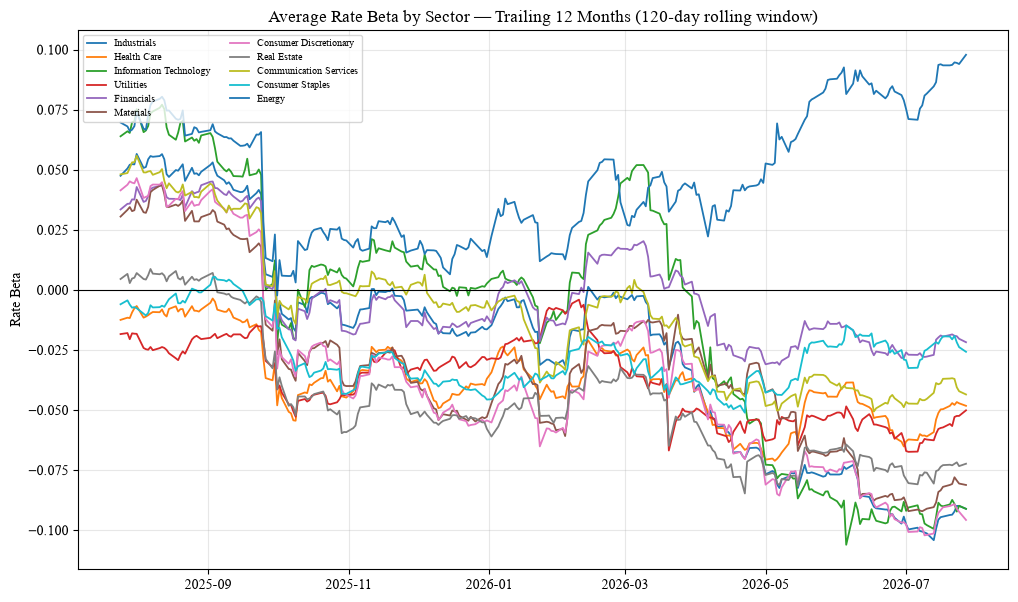

In [79]:
fig, ax = plt.subplots(figsize=(12, 7))

for sector in sector_beta_series.columns:
    ax.plot(sector_beta_series.index, sector_beta_series[sector], linewidth=1.3, label=sector)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Average Rate Beta by Sector — Trailing 12 Months (120-day rolling window)", fontsize=12)
ax.set_ylabel("Rate Beta")
ax.legend(loc="upper left", fontsize=7, ncol=2)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

NameError: name 'mdates' is not defined

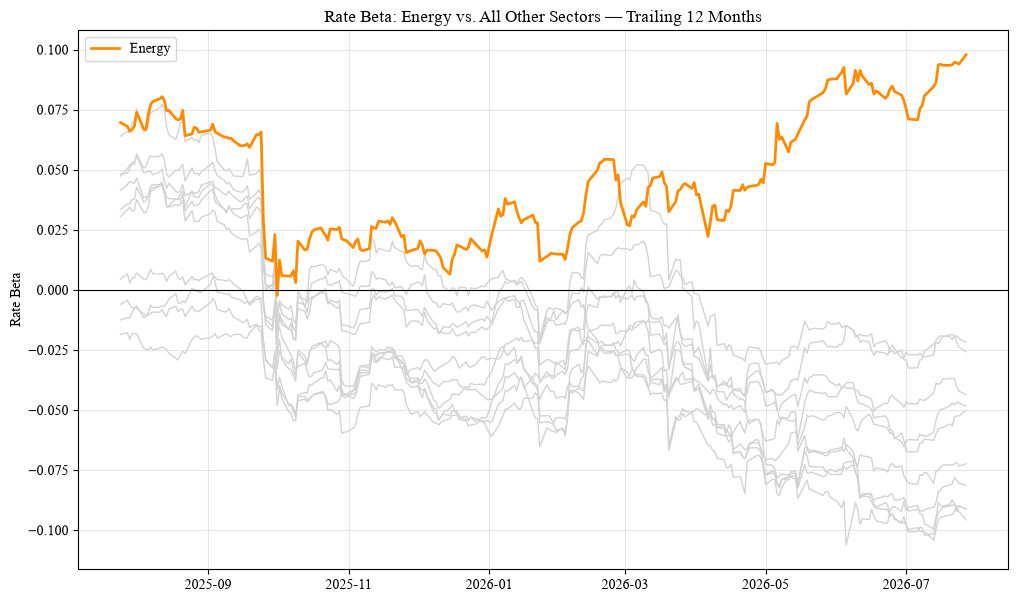

In [80]:
fig, ax = plt.subplots(figsize=(12, 7))

for sector in sector_beta_series.columns:
    if sector == "Energy":
        continue
    ax.plot(sector_beta_series.index, sector_beta_series[sector], linewidth=1, color="lightgrey")

ax.plot(sector_beta_series.index, sector_beta_series["Energy"], linewidth=2, color="darkorange", label="Energy")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Rate Beta: Energy vs. All Other Sectors — Trailing 12 Months", fontsize=12)
ax.set_ylabel("Rate Beta")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()